# Phase 2 - EDA: Telco Customer Churn

Exploratory analysis of `churn_ml.customers`, read **directly from BigQuery** on your local machine.

**Goal:** understand the data so we can make informed preprocessing and modeling decisions.

Authentication uses Application Default Credentials (set up in Phase 0 via `gcloud auth application-default login`) - no key file needed.

> After exploring, jot decisions in the final "Takeaways" cell. Those drive `src/preprocess.py`.

## 1. Setup

Make the repo's `src/` package importable and load the project config.

In [2]:
import sys
from pathlib import Path

# Add the repo root to the path so `from src import ...` works from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config, data

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(config.summary())

project:  churn-predictor-ml-2026
region:   us-west1
table:    churn-predictor-ml-2026.churn_ml.customers


## 2. Load data from BigQuery

This pulls the full `customers` table into a DataFrame using your local ADC credentials. If you get an auth error, run `gcloud auth application-default login` in a terminal.

In [3]:
df = data.load_customers()
print(f"rows: {df.shape[0]:,}  |  columns: {df.shape[1]}")
df.head()

/Users/carolina/dev/vertex-churn-pipeline/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


rows: 7,043  |  columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9426-SXNHE,Female,0,False,False,2,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Bank transfer (automatic),18.75,53.15,False
1,3806-YAZOV,Female,0,False,False,3,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,56,False
2,3387-PLKUI,Female,0,True,True,13,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.80,251.25,False
3,8992-CEUEN,Female,0,False,False,1,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Electronic check,18.85,18.85,False
4,0620-XEFWH,Male,0,True,True,4,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,False,Mailed check,18.85,84.2,False


In [14]:
df.shape

(7043, 21)

## 3. Structure & dtypes

Note which columns are numeric vs object (categorical). Watch for `TotalCharges` showing up as `object` - that's the known STRING quirk from the CSV load.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   Int64  
 3   Partner           7043 non-null   boolean
 4   Dependents        7043 non-null   boolean
 5   tenure            7043 non-null   Int64  
 6   PhoneService      7043 non-null   boolean
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   boolean


In [ ]:
# Numeric summary (TotalCharges is missing here because it is still a string)
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


- Senior Citizen is a flag (1-0): If customer is above certain age
- Tenure: Number of months that a customer has been with the company (could be correlated with churn - new customers tend to churn more but this is a hypothesis that should be verified)
- Monthly Charges: Amount paid monthly by the customer (TotalCharges should be roughly the MonthlyCharges times tenure)

- Also Total Charges needs to be converted from object to float

In [6]:
# Convert TotalCharges from object (string) to float.
# errors="coerce" turns the blank strings (new customers) into NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("dtype now:", df["TotalCharges"].dtype)
print("NaNs after conversion:", df["TotalCharges"].isna().sum())

# describe again - TotalCharges now shows up as a numeric column
df.describe(include="number").T

dtype now: float64
NaNs after conversion: 11


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.8,401.45,1397.475,3794.7375,8684.8


## 4. Missing & blank values

The Telco dataset has almost no `NaN`s, except for `TotalCharges` that contains 11 `NaN`s for brand-new customers (`tenure = 0`). We surface those here so we can decide how to handle them in preprocessing.

In [11]:
# Standard null check
print("Null counts:")
print(df.isna().sum())


Null counts:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
#tenure is always 0 for these customers
df[df.TotalCharges.isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3972,2923-ARZLG,Male,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,NaN,False
5532,7644-OMVMY,Male,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,19.85,NaN,False
5578,2520-SGTTA,Female,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,NaN,False
5643,3115-CZMZD,Male,0,False,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,NaN,False
5917,3213-VVOLG,Male,0,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,NaN,False
5956,4367-NUYAO,Male,0,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,NaN,False
6068,4472-LVYGI,Female,0,True,True,0,False,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,True,Bank transfer (automatic),52.55,NaN,False
6104,1371-DWPAZ,Female,0,True,True,0,False,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,False,Credit card (automatic),56.05,NaN,False
6174,2775-SEFEE,Male,0,False,True,0,True,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,True,Bank transfer (automatic),61.90,NaN,False
6303,4075-WKNIU,Female,0,True,True,0,True,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,False,Mailed check,73.35,NaN,False


In [15]:
df[df.tenure == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3972,2923-ARZLG,Male,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,NaN,False
5532,7644-OMVMY,Male,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,19.85,NaN,False
5578,2520-SGTTA,Female,0,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,NaN,False
5643,3115-CZMZD,Male,0,False,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,NaN,False
5917,3213-VVOLG,Male,0,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,NaN,False
5956,4367-NUYAO,Male,0,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,NaN,False
6068,4472-LVYGI,Female,0,True,True,0,False,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,True,Bank transfer (automatic),52.55,NaN,False
6104,1371-DWPAZ,Female,0,True,True,0,False,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,False,Credit card (automatic),56.05,NaN,False
6174,2775-SEFEE,Male,0,False,True,0,True,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,True,Bank transfer (automatic),61.90,NaN,False
6303,4075-WKNIU,Female,0,True,True,0,True,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,False,Mailed check,73.35,NaN,False


In [17]:
# Verify the assumption: are the blank/NaN TotalCharges exactly the tenure == 0 customers?
# (Run this AFTER the cell that converts TotalCharges to float.)
zero_tenure = df[df["tenure"] == 0]
nan_charges = df[df["TotalCharges"].isna()]

print("Rows with tenure == 0:        ", len(zero_tenure))
print("  of those, NaN TotalCharges: ", zero_tenure["TotalCharges"].isna().sum())
print("Rows with NaN TotalCharges:   ", len(nan_charges))
print("  of those, tenure == 0:      ", int((nan_charges["tenure"] == 0).sum()))

every_zero_is_nan = zero_tenure["TotalCharges"].isna().all()
every_nan_is_zero = (nan_charges["tenure"] == 0).all()
print("\nEvery tenure==0 has NaN TotalCharges:", every_zero_is_nan)
print("Every NaN TotalCharges has tenure==0:", every_nan_is_zero)
print("Perfect 1:1 match:", bool(every_zero_is_nan and every_nan_is_zero))

Rows with tenure == 0:         11
  of those, NaN TotalCharges:  11
Rows with NaN TotalCharges:    11
  of those, tenure == 0:       11

Every tenure==0 has NaN TotalCharges: True
Every NaN TotalCharges has tenure==0: True
Perfect 1:1 match: True


So it is safe to assume for this dataset that Total Charges is NaN everytime tenure = 0. It would be good to double check if this is a rule and if production data comes always like that. I would add a flag in data pipeline to check for any Total Charges NaN with Tenure != 0. As a fallback I would drop this row considering it might be an error.

## 5. Target balance

How many customers churned? This dataset is **imbalanced** (~26% churn), which informs our choice of metrics (favor recall/F1/ROC-AUC over raw accuracy) and class weighting in the model.

       count   pct
Churn             
False   5174  73.5
True    1869  26.5


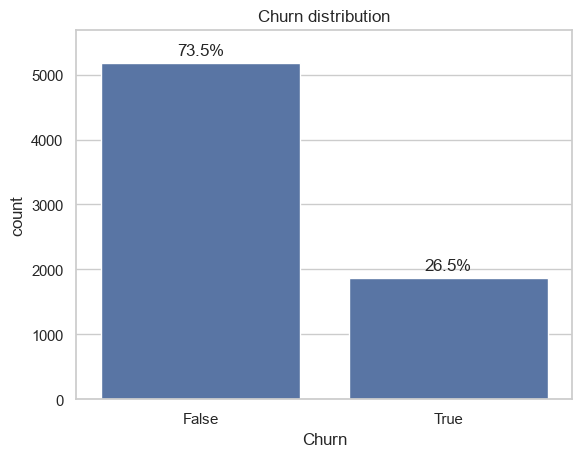

In [24]:
counts = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([counts, pct], axis=1, keys=["count", "pct"]))

total = len(df)
ax = sns.countplot(data=df, x="Churn")
# Label each bar with its share of the total (height / total rows).
for container in ax.containers:
    labels = [f"{bar.get_height() / total * 100:.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=3)
ax.set_title("Churn distribution")
ax.margins(y=0.1)  # headroom so the top labels aren't clipped
plt.show()

## 6. Numeric features vs Churn

After casting `TotalCharges` to numeric for analysis (coerce blanks to NaN), look at the distributions of `tenure`, `MonthlyCharges`, and `TotalCharges`, split by churn.

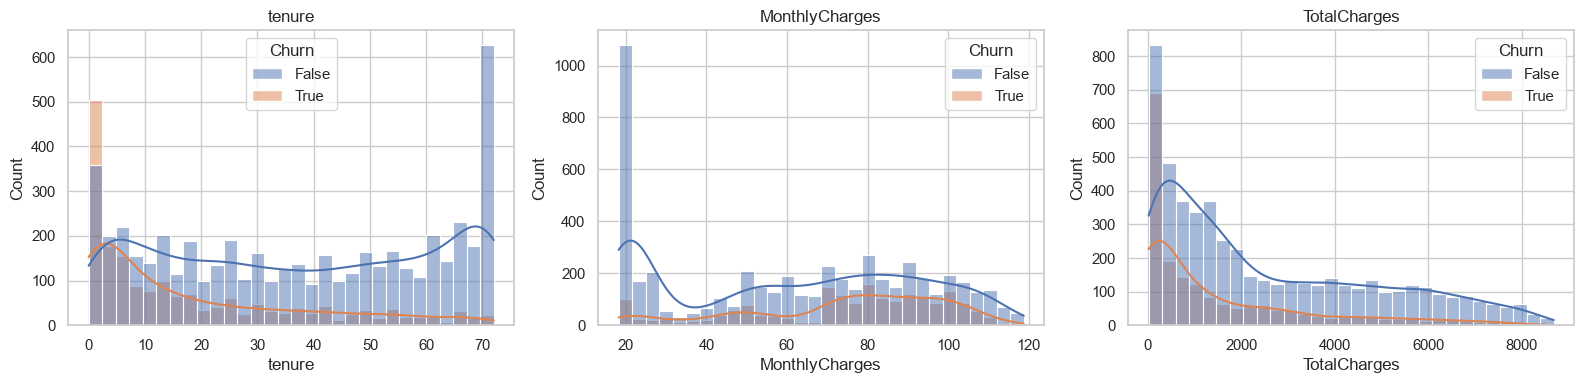

In [23]:
# Work on a copy so we don't mutate the raw df during EDA.
eda = df.copy()
eda["TotalCharges"] = pd.to_numeric(eda["TotalCharges"], errors="coerce")

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=eda, x=col, hue="Churn", bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

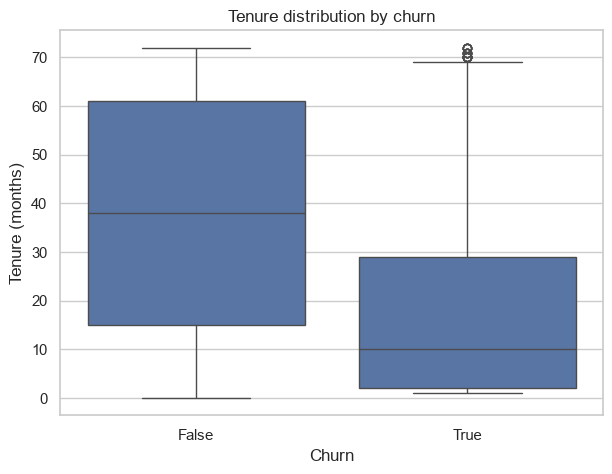

        25%   50%   75%
Churn                  
False  15.0  38.0  61.0
True    2.0  10.0  29.0


In [27]:
# Tenure distribution by churn - box plot
plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=eda, x="Churn", y="tenure")
ax.set_title("Tenure distribution by churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (months)")
plt.show()

# Median tenure per group makes the gap explicit
print(eda.groupby("Churn")["tenure"].describe()[["25%", "50%", "75%"]])

It seems that there is a correlation between churn and tenure

## 7. Categorical features vs churn

Churn rate broken down by key categorical features. `Contract`, `InternetService`, and `PaymentMethod` are usually strong signals.

churn_flag value counts:
 churn_flag
0    5174
1    1869
Name: count, dtype: int64


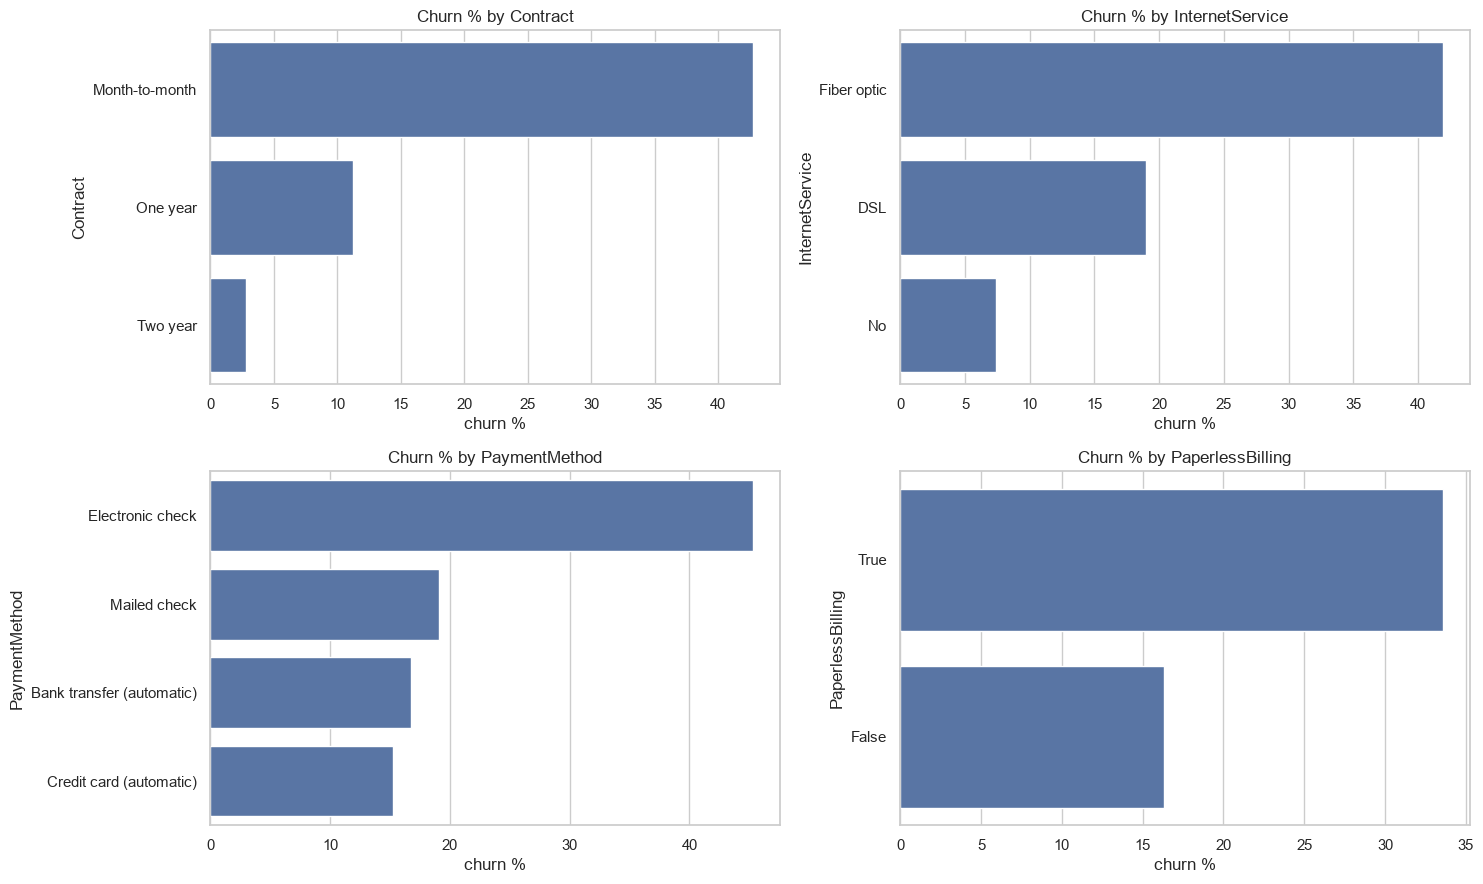

In [30]:
# Churn is loaded from BigQuery as a boolean (True/False).
# astype(int) maps True -> 1 (churned), False -> 0 (retained).
eda["churn_flag"] = eda["Churn"].astype(int)
print("churn_flag value counts:\n", eda["churn_flag"].value_counts())

cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = eda.groupby(col)["churn_flag"].mean().mul(100).sort_values(ascending=False)
    # Cast index to str so boolean columns (e.g. PaperlessBilling) render as
    # discrete category bars instead of a continuous 0-1 axis.
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax)
    ax.set_title(f"Churn % by {col}")
    ax.set_xlabel("churn %")
plt.tight_layout()
plt.show()

churn_flag value counts:
 churn_flag
0    5174
1    1869
Name: count, dtype: int64


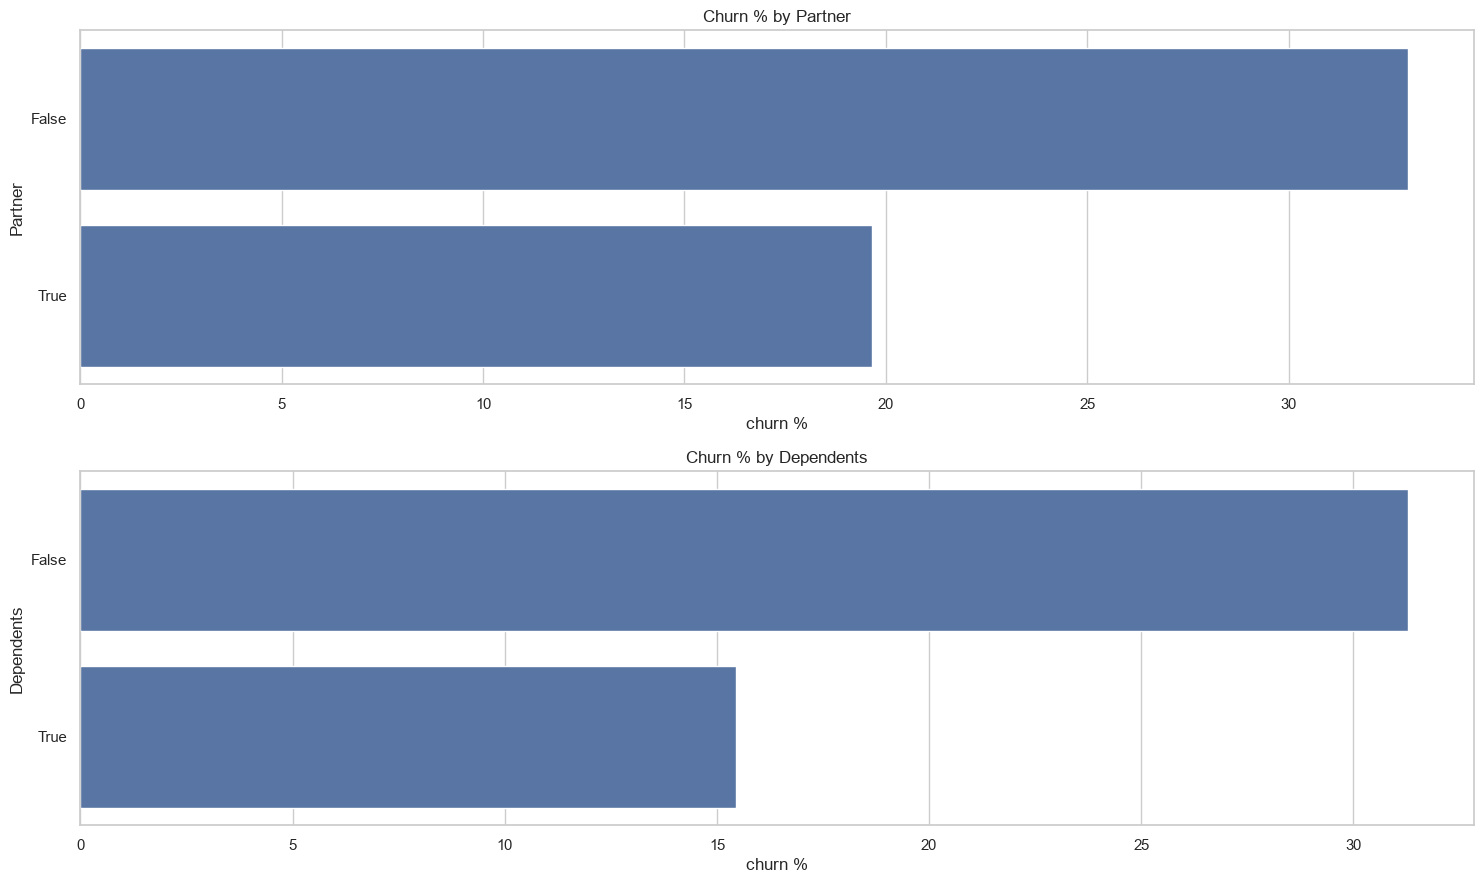

In [58]:
# Churn is loaded from BigQuery as a boolean (True/False).
# astype(int) maps True -> 1 (churned), False -> 0 (retained).
eda["churn_flag"] = eda["Churn"].astype(int)
print("churn_flag value counts:\n", eda["churn_flag"].value_counts())

cat_cols = ["Partner", "Dependents"]
fig, axes = plt.subplots(2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = eda.groupby(col)["churn_flag"].mean().mul(100).sort_values(ascending=False)
    # Cast index to str so boolean columns (e.g. PaperlessBilling) render as
    # discrete category bars instead of a continuous 0-1 axis.
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax)
    ax.set_title(f"Churn % by {col}")
    ax.set_xlabel("churn %")
plt.tight_layout()
plt.show()

## 8. Correlation (numeric + encoded)

A quick correlation heatmap after one-hot encoding, to spot features most associated with churn. This is exploratory only - the real encoding happens in `src/preprocess.py`.

Top 15 features correlated with churn:
tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
OnlineBackup_No internet service       -0.227890
StreamingMovies_No internet service    -0.227890
StreamingTV_No internet service        -0.227890
OnlineSecurity_No internet service     -0.227890
InternetService_No                     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
TotalCharges                           -0.199484
MonthlyCharges                          0.193356
PaperlessBilling                        0.191825
Contract_One year                      -0.177820
Name: churn_flag, dtype: float64


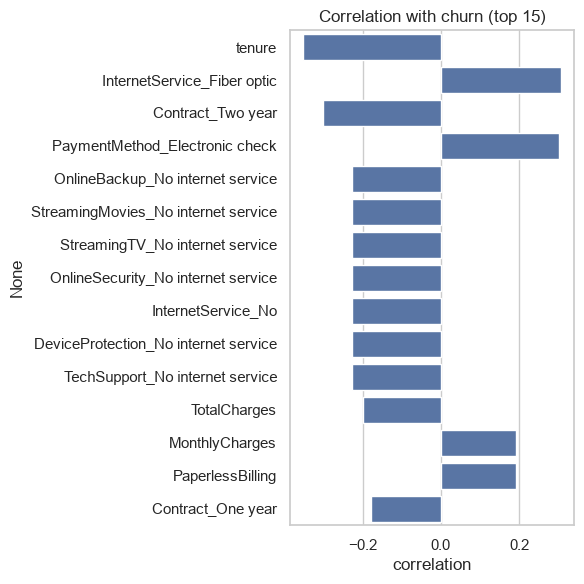

In [52]:
features = eda.drop(columns=["customerID", "Churn"])
encoded = pd.get_dummies(features, drop_first=True)
encoded["churn_flag"] = eda["churn_flag"]

corr_with_churn = (
    encoded.corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=abs, ascending=False)
)
print("Top 15 features correlated with churn:")
print(corr_with_churn.head(15))

plt.figure(figsize=(6, 6))
sns.barplot(x=corr_with_churn.head(15).values, y=corr_with_churn.head(15).index)
plt.title("Correlation with churn (top 15)")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

Here we are dropping the Month-to-Month contract with the drop_first = True parameter but we can still see the correlation based on the Contract_Two_year var that has a strong negative correlation with the target

Top 15 features correlated with churn:
Contract_Month-to-month                 0.405103
tenure                                 -0.352229
OnlineSecurity_No                       0.342637
TechSupport_No                          0.337281
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
OnlineBackup_No                         0.268005
DeviceProtection_No                     0.252481
TechSupport_No internet service        -0.227890
OnlineSecurity_No internet service     -0.227890
InternetService_No                     -0.227890
OnlineBackup_No internet service       -0.227890
StreamingTV_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
Name: churn_flag, dtype: float64


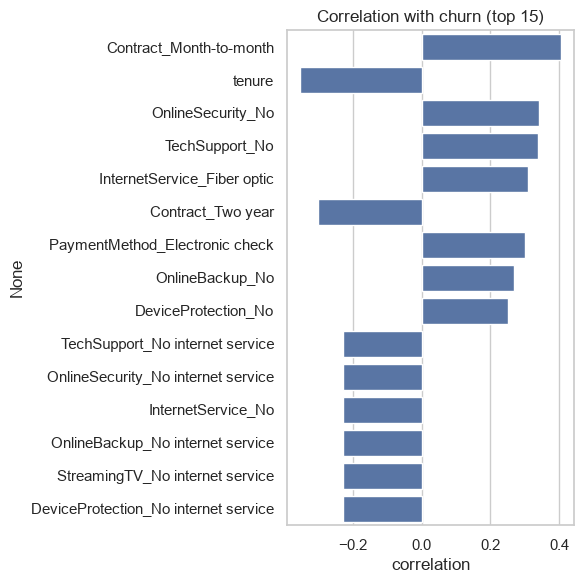

In [53]:
features = eda.drop(columns=["customerID", "Churn"])
encoded = pd.get_dummies(features, drop_first=False)
encoded["churn_flag"] = eda["churn_flag"]

corr_with_churn = (
    encoded.corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=abs, ascending=False)
)
print("Top 15 features correlated with churn:")
print(corr_with_churn.head(15))

plt.figure(figsize=(6, 6))
sns.barplot(x=corr_with_churn.head(15).values, y=corr_with_churn.head(15).index)
plt.title("Correlation with churn (top 15)")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

If we remove the drop first, then we see the Month-to-Month as the greatest correlation. For tree based models we dont need to worry about multicolinearity so we dont need to use the drop first, but for logistic regression (a model that might be used as a baseline) yes.

Top 15 features correlated with churn:
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226
Contract_On

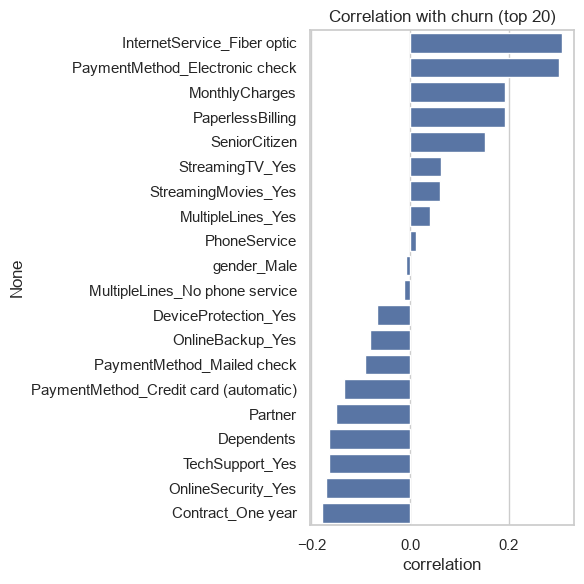

In [49]:
features = eda.drop(columns=["customerID", "Churn"])
encoded = pd.get_dummies(features, drop_first=True)
encoded["churn_flag"] = eda["churn_flag"]

corr_with_churn = (
    encoded.corr(numeric_only=True)["churn_flag"]
    .drop("churn_flag")
    .sort_values(ascending=False)
)
print("Top 15 features correlated with churn:")
print(corr_with_churn.head(20))

plt.figure(figsize=(6, 6))
sns.barplot(x=corr_with_churn.head(20).values, y=corr_with_churn.head(20).index)
plt.title("Correlation with churn (top 20)")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

Interesting that even though it seems that dependents and partner has some correlation with the target, it is not as strong I imagined.

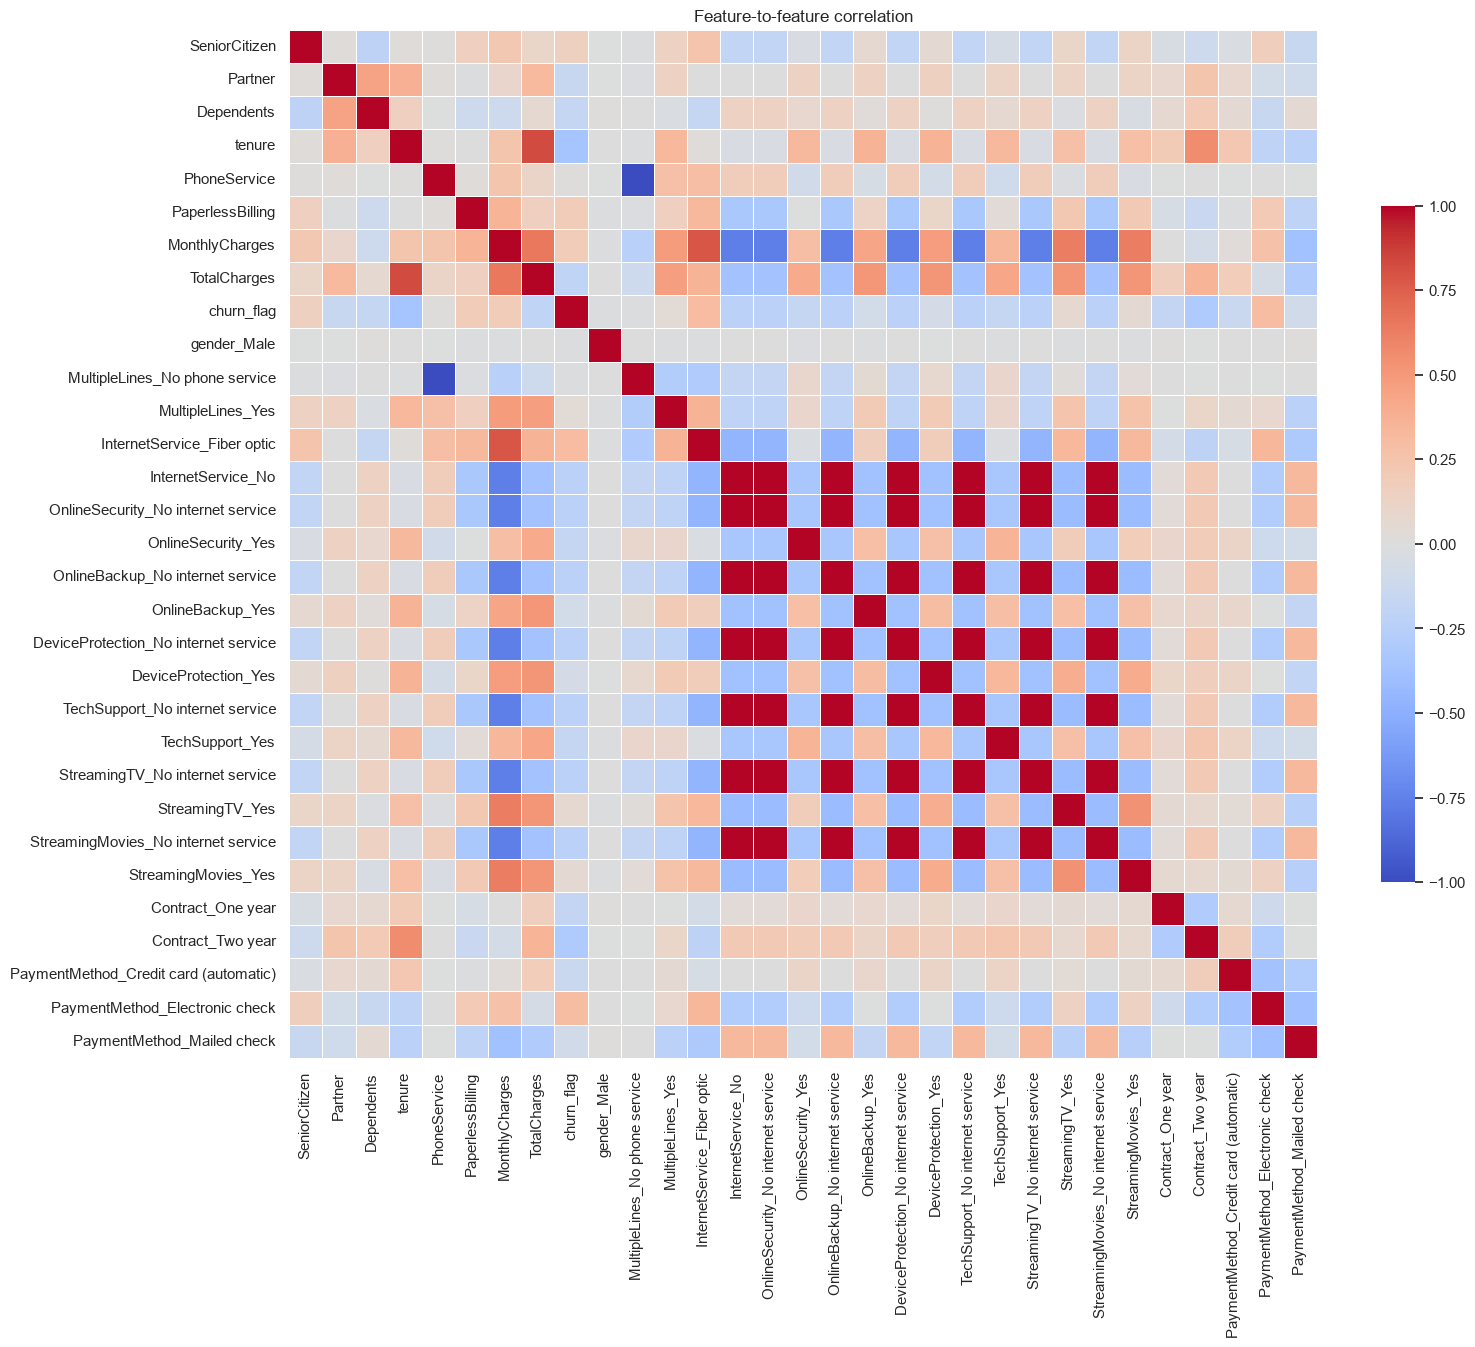

Most correlated feature pairs (|r| descending):
+1.00  DeviceProtection_No internet service  <->  InternetService_No
+1.00  StreamingTV_No internet service  <->  StreamingMovies_No internet service
+1.00  InternetService_No  <->  TechSupport_No internet service
+1.00  InternetService_No  <->  OnlineBackup_No internet service
+1.00  InternetService_No  <->  OnlineSecurity_No internet service
+1.00  TechSupport_No internet service  <->  OnlineSecurity_No internet service
+1.00  TechSupport_No internet service  <->  OnlineBackup_No internet service
+1.00  TechSupport_No internet service  <->  DeviceProtection_No internet service
+1.00  TechSupport_No internet service  <->  StreamingTV_No internet service
+1.00  TechSupport_No internet service  <->  StreamingMovies_No internet service


In [38]:
# Correlation heatmap including the target (churn_flag), so you can see both
# feature-to-feature multicollinearity and each feature's relation to churn.
corr = encoded.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.6},
)
plt.title("Feature-to-feature correlation")
plt.tight_layout()
plt.show()

# List the most strongly correlated feature pairs (helps spot redundancy).
pairs = corr.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
pairs = pairs.sort_values(key=abs, ascending=False)

seen = set()
print("Most correlated feature pairs (|r| descending):")
for (f1, f2), value in pairs.items():
    key = frozenset((f1, f2))
    if key in seen:
        continue
    seen.add(key)
    print(f"{value:+.2f}  {f1}  <->  {f2}")
    if len(seen) >= 10:
        break

Dropping 7 redundant dummies:
  - MultipleLines_No phone service
  - OnlineSecurity_No internet service
  - OnlineBackup_No internet service
  - DeviceProtection_No internet service
  - TechSupport_No internet service
  - StreamingTV_No internet service
  - StreamingMovies_No internet service


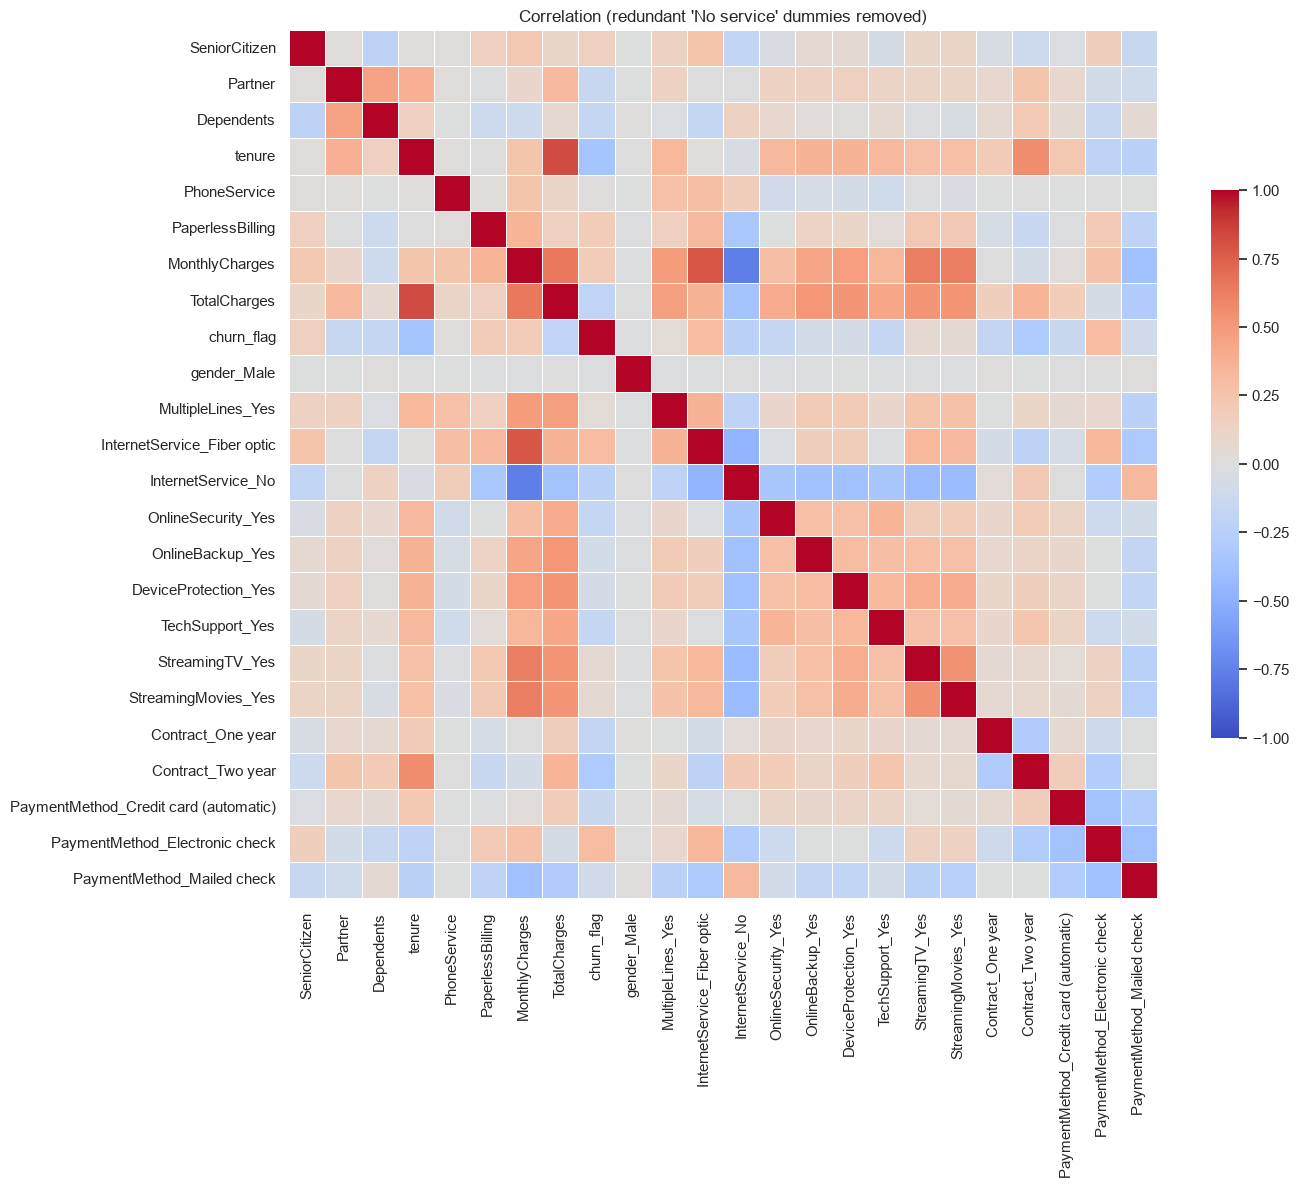


Most correlated feature pairs (filtered):
+0.83  TotalCharges  <->  tenure
+0.79  InternetService_Fiber optic  <->  MonthlyCharges
-0.76  InternetService_No  <->  MonthlyCharges
+0.65  MonthlyCharges  <->  TotalCharges
+0.63  StreamingTV_Yes  <->  MonthlyCharges
+0.63  MonthlyCharges  <->  StreamingMovies_Yes
+0.56  tenure  <->  Contract_Two year
+0.53  StreamingMovies_Yes  <->  StreamingTV_Yes
+0.52  DeviceProtection_Yes  <->  TotalCharges
+0.52  StreamingMovies_Yes  <->  TotalCharges


In [45]:
# The "No internet service" dummies are identical to InternetService_No, and
# "No phone service" mirrors PhoneService - redundant by construction.
# Drop them and recompute the correlation to see the real relationships.
redundant = [c for c in encoded.columns
             if "No internet service" in c or "No phone service" in c]
print(f"Dropping {len(redundant)} redundant dummies:")
for c in redundant:
    print("  -", c)

# Recompute from `encoded` directly so this cell is self-contained.
corr_f = encoded.drop(columns=redundant).corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr_f, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Correlation (redundant 'No service' dummies removed)")
plt.tight_layout()
plt.show()

pairs_f = corr_f.stack()
pairs_f = pairs_f[pairs_f.index.get_level_values(0) != pairs_f.index.get_level_values(1)]
pairs_f = pairs_f.sort_values(key=abs, ascending=False)

seen = set()
print("\nMost correlated feature pairs (filtered):")
for (f1, f2), value in pairs_f.items():
    key = frozenset((f1, f2))
    if key in seen:
        continue
    seen.add(key)
    print(f"{value:+.2f}  {f1}  <->  {f2}")
    if len(seen) >= 10:
        break

## 8b. Feature idea: average charge vs current monthly charge

Hypothesis: `avg_charge = TotalCharges / tenure` is the customer's *historical* average monthly spend. If it differs from the *current* `MonthlyCharges`, the customer's plan changed over time (upgrade/downgrade). That gap (`MonthlyCharges - avg_charge`) might carry churn signal.

Note: `tenure = 0` customers (new, blank `TotalCharges`) are excluded since `avg_charge` is undefined for them.

                 count       mean        std     min        25%        50%  \
MonthlyCharges  7032.0  64.798208  30.085974   18.25    35.5875      70.35   
avg_charge      7032.0  64.799424  30.185891  13.775  36.179891  70.373239   
charge_diff     7032.0  -0.001215   2.616165   -18.9  -1.160179        0.0   

                     75%     max  
MonthlyCharges   89.8625  118.75  
avg_charge      90.17956   121.4  
charge_diff     1.147775  19.125  

Mean |charge_diff|:         1.75
Corr MonthlyCharges vs avg_charge: 0.996


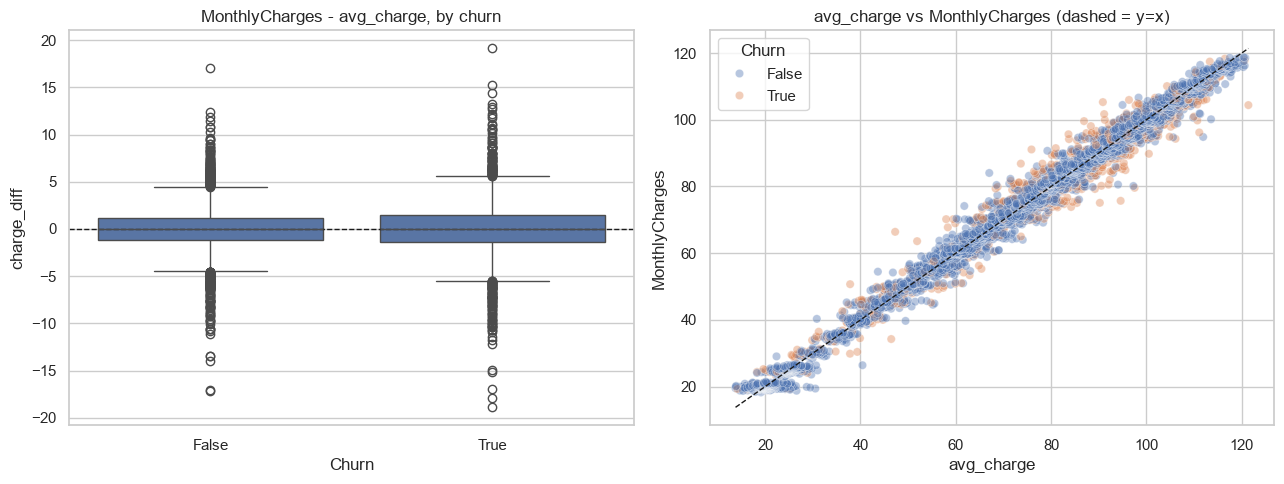


Churn % by whether current charge > historical average:
charge_increased
False    29.3
True     23.3
Name: churn_flag, dtype: float64


In [39]:
fe = eda.copy()

# Historical average monthly spend; only defined where tenure > 0.
fe["avg_charge"] = fe["TotalCharges"] / fe["tenure"].where(fe["tenure"] > 0)
# Gap between current monthly charge and historical average.
fe["charge_diff"] = fe["MonthlyCharges"] - fe["avg_charge"]

valid = fe.dropna(subset=["avg_charge"])
print(valid[["MonthlyCharges", "avg_charge", "charge_diff"]].describe().T)
print("\nMean |charge_diff|:        ", round(valid["charge_diff"].abs().mean(), 2))
print("Corr MonthlyCharges vs avg_charge:",
      round(valid["MonthlyCharges"].corr(valid["avg_charge"]), 3))

# Visualize: does the gap relate to churn?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=valid, x="Churn", y="charge_diff", ax=axes[0])
axes[0].axhline(0, color="k", linewidth=1, linestyle="--")
axes[0].set_title("MonthlyCharges - avg_charge, by churn")

sns.scatterplot(data=valid, x="avg_charge", y="MonthlyCharges",
                hue="Churn", alpha=0.4, ax=axes[1])
lims = [valid[["avg_charge", "MonthlyCharges"]].min().min(),
        valid[["avg_charge", "MonthlyCharges"]].max().max()]
axes[1].plot(lims, lims, "k--", linewidth=1)  # y = x: points off this line changed plans
axes[1].set_title("avg_charge vs MonthlyCharges (dashed = y=x)")
plt.tight_layout()
plt.show()

# Churn rate split by whether the current charge is higher than the historical average.
churn_by_direction = (
    valid.assign(charge_increased=valid["charge_diff"] > 0)
    .groupby("charge_increased")["churn_flag"].mean().mul(100).round(1)
)
print("\nChurn % by whether current charge > historical average:")
print(churn_by_direction)

## 8c. `drop_first` in practice: collinearity vs. clean odds ratios

A quick demo of *why* the `drop_first` choice matters for logistic regression.

- **`drop_first=False`** keeps all 3 `Contract` dummies, which are perfectly collinear (`Month + One + Two = 1`). The coefficients are not uniquely identified, so the split across the columns shifts when we change the regularization strength `C`.
- **`drop_first=True`** drops month-to-month, making it the baseline. The coefficients are stable, and `exp(coef)` reads as a clean **odds ratio vs. month-to-month**.

(Numeric columns are standardized so the model converges; the 0/1 dummies are left as-is so `exp(coef)` stays interpretable as an odds ratio.)

In [55]:
import numpy as np
from sklearn.linear_model import LogisticRegression

y = eda["churn_flag"]
base = eda.drop(columns=["customerID", "Churn", "churn_flag"])
mask = base["TotalCharges"].notna()  # drop the few NaN rows so the model can fit

# Scale numeric columns only; leave 0/1 dummies untouched so exp(coef) stays a clean odds ratio.
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

def make_X(drop_first):
    X = pd.get_dummies(base[mask], drop_first=drop_first).astype(float)
    X[num_cols] = (X[num_cols] - X[num_cols].mean()) / X[num_cols].std()
    return X

def contract_coefs(drop_first, C):
    X = make_X(drop_first)
    model = LogisticRegression(max_iter=5000, C=C).fit(X, y[mask])
    coefs = pd.Series(model.coef_[0], index=X.columns)
    return coefs[[c for c in X.columns if c.startswith("Contract_")]]

print("drop_first=False  (all 3 Contract dummies kept) - coefficients shift with regularization:")
print("  C=1.0 :", contract_coefs(False, 1.0).round(3).to_dict())
print("  C=100 :", contract_coefs(False, 100).round(3).to_dict())
print("  -> the split across the 3 collinear columns is not uniquely identified\n")

print("drop_first=True   (month-to-month = baseline) - stable, clean odds ratios:")
for name, beta in contract_coefs(True, 1.0).items():
    print(f"  {name:<20} beta={beta:+.3f}   odds ratio vs month-to-month = {np.exp(beta):.2f}")

drop_first=False  (all 3 Contract dummies kept) - coefficients shift with regularization:
  C=1.0 : {'Contract_Month-to-month': 0.536, 'Contract_One year': -0.129, 'Contract_Two year': -0.799}
  C=100 : {'Contract_Month-to-month': 0.536, 'Contract_One year': -0.126, 'Contract_Two year': -0.812}
  -> the split across the 3 collinear columns is not uniquely identified

drop_first=True   (month-to-month = baseline) - stable, clean odds ratios:
  Contract_One year    beta=-0.648   odds ratio vs month-to-month = 0.52
  Contract_Two year    beta=-1.316   odds ratio vs month-to-month = 0.27


## 9. Takeaways (after exploring)

Decisions that will shape `src/preprocess.py` and `src/train.py` in Stage B.

#### Data cleaning

- **`TotalCharges` blanks:** if `tenure == 0`, fill with `0` (new customer, nothing billed yet). If `tenure != 0`, drop the row and log it as a likely data error.
- **Features to drop:** `customerID` (pure identifier, no signal); **`gender`** (protected attribute + ~0 correlation with churn) - drop it as a model feature but keep the column for later fairness analysis.

#### Feature encoding

- **Collapse redundant "no service" levels:** in the six internet add-ons (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) replace `"No internet service"` -> `"No"`, and in `MultipleLines` replace `"No phone service"` -> `"No"`. This is lossless because `InternetService` / `PhoneService` already carry the no-service signal, and it removes the 6+ perfectly-collinear dummies that dominated the raw correlations.
- **One-hot encoding:** all categoricals are low-cardinality, so one-hot encode them (no high-cardinality or ordinal columns to special-case).
- **`drop_first`:** use `True` for Logistic Regression (avoids the dummy-variable trap / perfect multicollinearity and gives clean odds-ratio coefficients vs. a baseline); use `False` for EDA and tree models (XGBoost), which aren't hurt by collinearity and benefit from seeing every category.

#### Key findings

- **Contract length** is one of the strongest churn drivers: ~43% of month-to-month customers churn (a within-group rate, not a share of all churners) vs ~11% one-year and ~3% two-year.
- **Other strong signals:** `InternetService = Fiber optic` and `PaymentMethod = Electronic check` push churn up; longer `tenure` and longer contracts push it down.
- With `drop_first=True`, month-to-month becomes the baseline, so its strong signal shows up indirectly as the negative `Contract_One year` / `Contract_Two year` correlations.

#### Modeling decisions

- **Models:** Logistic Regression (interpretable baseline) + XGBoost (performance).
- **Class imbalance:** use class weights (dataset is small). With more data, downsampling would be an option - never upsampling, which adds noise and generalizes poorly.
- **Split / validation:** 80/20 split stratified on `Churn`, `random_state=42`; stratified 5-fold CV on the training set for tuning.
- **Primary metric:** recall / PR-AUC (business goal = catch as many churners as possible). Also report ROC-AUC, precision, and F1, and tune the decision threshold rather than assuming 0.5.
- **Encoding pipeline:** sklearn `Pipeline` + `ColumnTransformer` with `OneHotEncoder(handle_unknown="ignore")` and `StandardScaler` (numerics, for Logistic Regression). Fit on train only to avoid leakage; save the whole pipeline as one artifact for the model registry.
- **Engineered features:** start with a clean baseline (no `avg_charge` / `charge_increased`); add them as a follow-up experiment to measure their lift.
- **Fair comparison:** both models get the *same feature set* (no buckets); only the representation differs (scale numerics for LogReg, trees skip it). Baseline LogReg stays at defaults + balanced weights; only the XGBoost candidate is tuned.
- **Fairness audit:** `gender` is excluded from training, but retained to slice evaluation metrics by gender and check for disparate impact via proxy features.

#### Other observations

- ->